Generate synthetic vector embeddings

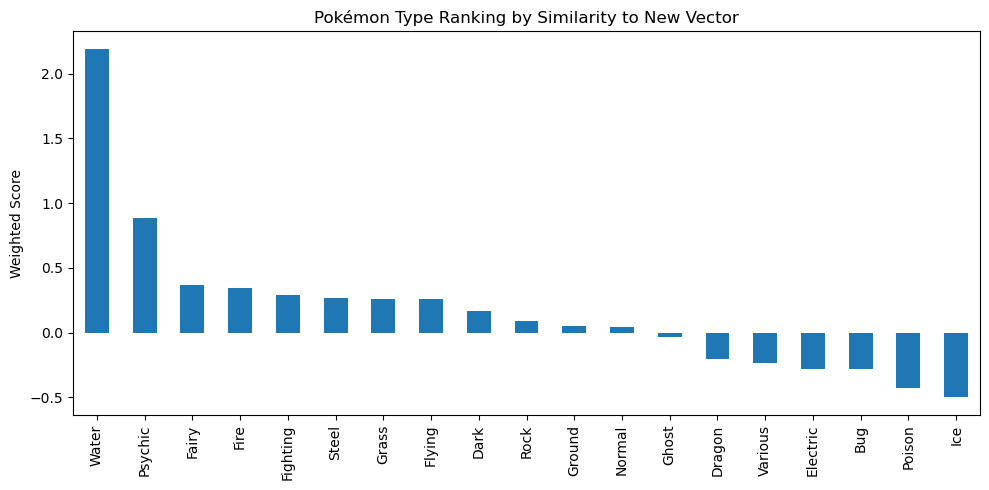

/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_45331/2782833719.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(types))


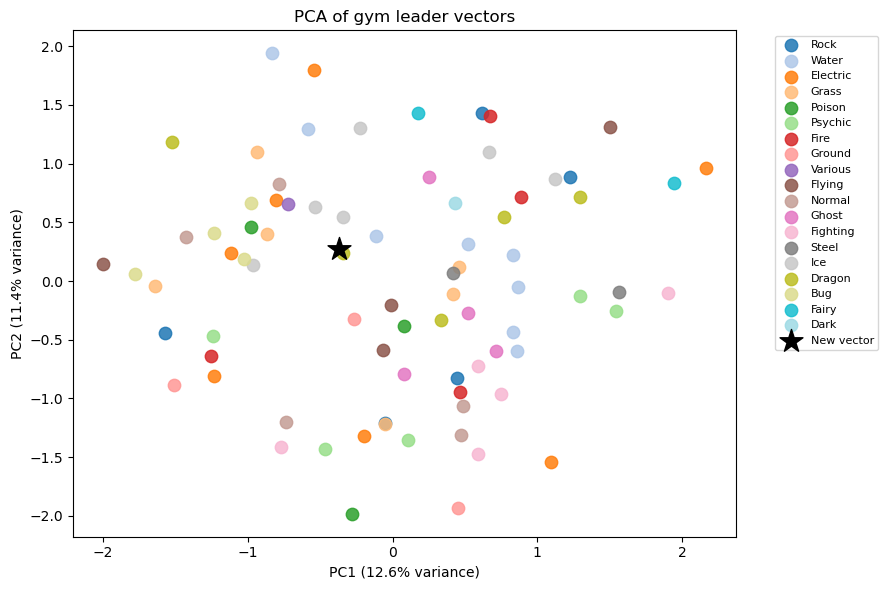

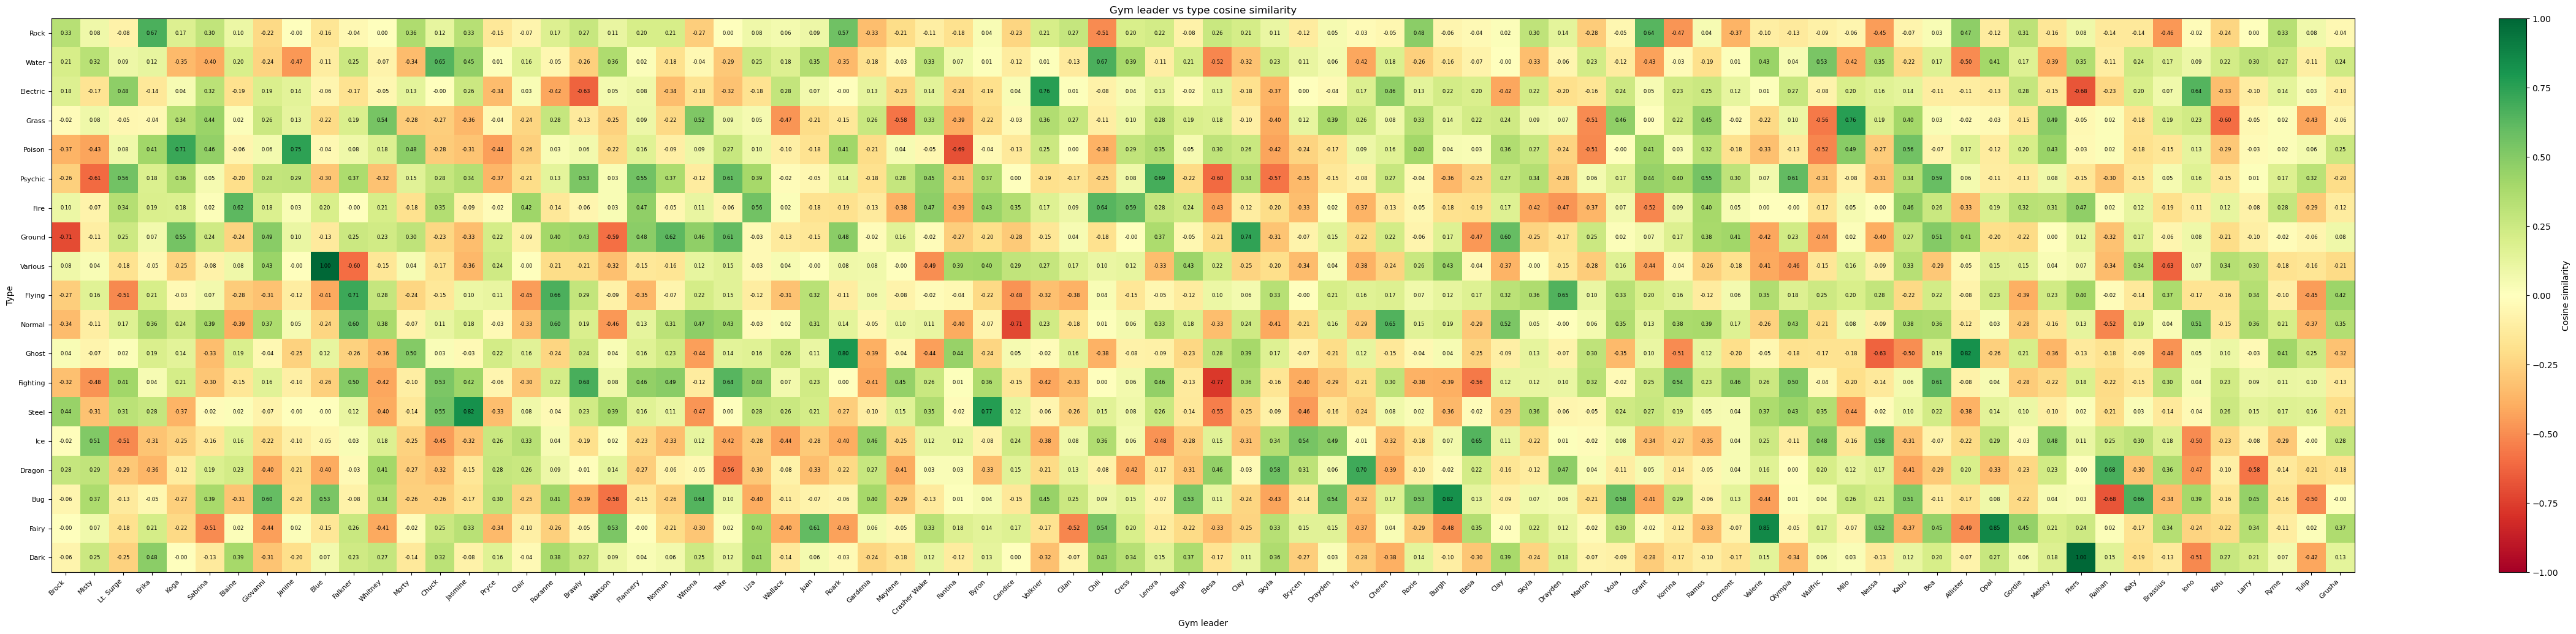

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def cosine_similarity(vector, vectors):
    dot_products = vectors @ vector
    norms = np.linalg.norm(vectors, axis=1) * np.linalg.norm(vector)
    return dot_products / norms


def rank_types_by_similarity(new_vector, vectors, df):
    cosine_similarities = cosine_similarity(new_vector, vectors)

    type_vectors = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        weights = cosine_similarities[mask]

        if np.sum(weights) == 0:
            type_vectors[pokemon_type] = np.mean(vectors[mask], axis=0)
        else:
            type_vectors[pokemon_type] = np.average(vectors[mask], axis=0, weights=weights)

    scores = {pokemon_type: vec.mean() for pokemon_type, vec in type_vectors.items()}
    ranking = pd.Series(scores).sort_values(ascending=False)
    return ranking


def plot_pca(new_vector, vectors, df):
    """
    Project gym leader vectors + the new vector into 2D via PCA.
    Each point is colored by Pokémon type; the new vector is shown as a star.
    """
    all_vectors = np.vstack([vectors, new_vector])

    pca = PCA(n_components=2)
    projected = pca.fit_transform(all_vectors)

    leader_proj = projected[:-1]
    new_proj = projected[-1]

    types = df["Type"].unique()
    cmap = plt.cm.get_cmap("tab20", len(types))
    type_to_color = {t: cmap(i) for i, t in enumerate(types)}

    fig, ax = plt.subplots(figsize=(9, 6))

    for pokemon_type in types:
        mask = df["Type"] == pokemon_type
        ax.scatter(
            leader_proj[mask, 0],
            leader_proj[mask, 1],
            label=pokemon_type,
            color=type_to_color[pokemon_type],
            s=80,
            alpha=0.85,
        )

    ax.scatter(
        new_proj[0], new_proj[1],
        marker="*", s=300, color="black", zorder=5, label="New vector"
    )

    var_explained = pca.explained_variance_ratio_ * 100
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
    ax.set_title("PCA of gym leader vectors")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_similarity_heatmap(vectors, df):
    """
    Compute cosine similarity between each gym leader and each type centroid,
    rendered as an annotated heatmap (types × leaders).
    """
    type_centroids = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        type_centroids[pokemon_type] = vectors[mask].mean(axis=0)

    types = list(type_centroids.keys())
    centroids = np.array([type_centroids[t] for t in types])

    # Normalize rows before dot product for cosine similarity
    def safe_normalize(mat):
        norms = np.linalg.norm(mat, axis=1, keepdims=True)
        return mat / np.where(norms == 0, 1, norms)

    norm_centroids = safe_normalize(centroids)
    norm_vectors = safe_normalize(vectors)

    sim_matrix = norm_centroids @ norm_vectors.T  # shape: (n_types, n_leaders)

    leaders = df["Leader"].tolist()
    n_types = len(types)
    n_leaders = len(leaders)

    fig, ax = plt.subplots(figsize=(max(8, n_leaders * 0.6), max(5, n_types * 0.55)))
    im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap="RdYlGn", aspect="auto")

    plt.colorbar(im, ax=ax, label="Cosine similarity")

    ax.set_xticks(range(n_leaders))
    ax.set_yticks(range(n_types))
    ax.set_xticklabels(leaders, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(types, fontsize=8)

    for i in range(n_types):
        for j in range(n_leaders):
            ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center",
                    fontsize=6, color="black")

    ax.set_title("Gym leader vs type cosine similarity")
    ax.set_xlabel("Gym leader")
    ax.set_ylabel("Type")
    plt.tight_layout()
    plt.show()

# --- Main ---
df_synth = pd.read_csv("gym_leaders_synthetic.csv")
values = [-1, -0.5, 0, 0.5, 1]
new_vector = np.random.choice(values, size=15)  # 15 questions for the new vector

ranking = rank_types_by_similarity(new_vector, vectors, df)
plot_ranking(ranking)
plot_pca(new_vector, vectors, df)
plot_similarity_heatmap(vectors, df)